In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
import os

print("=== Checking Titanic Dataset ===")
print("Current directory:", os.getcwd())

# List all input folders
print("\nAvailable input folders:")
print(os.listdir('/kaggle/input'))

# Try to find titanic files
print("\nTrying to list titanic folder:")
try:
    files = os.listdir('/kaggle/input/titanic')
    print("Success! Files found:", files)
except Exception as e:
    print("Error:", e)

=== Checking Titanic Dataset ===
Current directory: /kaggle/working

Available input folders:
['competitions']

Trying to list titanic folder:
Error: [Errno 2] No such file or directory: '/kaggle/input/titanic'


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("=== Titanic Survival Prediction ===")

# Correct path for this notebook
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

# Feature Engineering
def feature_engineering(df):
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 
                                       'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace('Mlle', 'Miss')
    df['Title'] = df['Title'].replace('Ms', 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    df['Age'] = df.groupby(['Title', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    
    features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 
                'Embarked', 'FamilySize', 'IsAlone']
    return df[features]

# Prepare data
X = feature_engineering(train)
y = train['Survived']
X = pd.get_dummies(X, drop_first=True)

# Split and train
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Validate
pred_val = model.predict(X_val)
acc = accuracy_score(y_val, pred_val) * 100
print(f"\nValidation Accuracy: {acc:.2f}%")

# Test prediction
test_features = feature_engineering(test)
test_features = pd.get_dummies(test_features, drop_first=True)
test_features = test_features.reindex(columns=X.columns, fill_value=0)

test_pred = model.predict(test_features)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_pred
})

submission.to_csv('submission.csv', index=False)
print("\nSubmission file 'submission.csv' created successfully!")
print("You can download it from the right panel (Output section).")

<>:20: SyntaxWarning: invalid escape sequence '\.'
<>:20: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_16/246650225.py:20: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


=== Titanic Survival Prediction ===
Train shape: (891, 12)
Test shape: (418, 11)

Validation Accuracy: 81.56%

Submission file 'submission.csv' created successfully!
You can download it from the right panel (Output section).


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("=== Titanic - Improved Version (XGBoost) ===")

# Load data
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

def feature_engineering(df):
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace(['Mlle','Ms'], 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    df['FareBin'] = pd.qcut(df['Fare'], 5, duplicates='drop')
    df['AgeBin'] = pd.cut(df['Age'], [0,12,18,35,60,100], labels=['Child','Teen','Young','Middle','Senior'])
    
    df['Deck'] = df['Cabin'].str[0].fillna('U')
    
    df['Age'] = df.groupby(['Title', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
    df['Age'] = df['Age'].fillna(df['Age'].median())
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    
    features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
                'FamilySize', 'IsAlone', 'Title', 'Deck', 'AgeBin', 'FareBin']
    return df[features]

# Process
X = feature_engineering(train)
y = train['Survived']

X = pd.get_dummies(X, drop_first=True)

# Fix column names for XGBoost
X.columns = [str(col).replace('[', '_').replace(']', '_').replace('<', '_') for col in X.columns]

# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost
model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

pred_val = model.predict(X_val)
acc = accuracy_score(y_val, pred_val) * 100
print(f"Validation Accuracy: {acc:.2f}%")

# Test
test_features = feature_engineering(test)
test_features = pd.get_dummies(test_features, drop_first=True)
test_features.columns = [str(col).replace('[', '_').replace(']', '_').replace('<', '_') for col in test_features.columns]
test_features = test_features.reindex(columns=X.columns, fill_value=0)

test_pred = model.predict(test_features)

submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_pred
})

submission.to_csv('submission_improved.csv', index=False)
print("\nSubmission file 'submission_improved.csv' created!")

=== Titanic - Improved Version (XGBoost) ===
Validation Accuracy: 82.12%

Submission file 'submission_improved.csv' created!


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("=== Titanic - Optimized Version ===")

train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

def feature_engineering(df):
    df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace(['Mlle','Ms'], 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    df['FamilySizeBin'] = pd.cut(df['FamilySize'], bins=[0,1,4,7,11], labels=['Alone','Small','Medium','Large'])
    
    df['FareBin'] = pd.qcut(df['Fare'], 6, duplicates='drop')
    df['AgeBin'] = pd.cut(df['Age'], [0,12,18,25,35,60,100], labels=['Child','Teen','YoungAdult','Adult','Middle','Senior'])
    
    df['Deck'] = df['Cabin'].str[0].fillna('U')
    df['HasCabin'] = df['Cabin'].notna().astype(int)
    
    # Fill NA
    df['Age'] = df.groupby(['Title', 'Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
    df['Age'] = df['Age'].fillna(28)
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna('S')
    
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    
    features = ['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','FamilySize',
                'IsAlone','Title','Deck','HasCabin','AgeBin','FareBin','FamilySizeBin']
    return df[features]

X = feature_engineering(train)
y = train['Survived']
X = pd.get_dummies(X, drop_first=True)

# Clean column names
X.columns = [str(col).replace('[', '_').replace(']', '_').replace('<', '_').replace(',', '') for col in X.columns]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)

model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.85,
    colsample_bytree=0.85,
    gamma=0.1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

pred_val = model.predict(X_val)
acc = accuracy_score(y_val, pred_val) * 100
print(f"Validation Accuracy: {acc:.2f}%")

# Test
test_features = feature_engineering(test)
test_features = pd.get_dummies(test_features, drop_first=True)
test_features.columns = [str(col).replace('[', '_').replace(']', '_').replace('<', '_').replace(',', '') for col in test_features.columns]
test_features = test_features.reindex(columns=X.columns, fill_value=0)

test_pred = model.predict(test_features)

submission = pd.DataFrame({'PassengerId': test['PassengerId'], 'Survived': test_pred})
submission.to_csv('submission_optimized.csv', index=False)

print("New file 'submission_optimized.csv' created!")

=== Titanic - Optimized Version ===
Validation Accuracy: 84.33%
New file 'submission_optimized.csv' created!


In [6]:
import pandas as pd

# Load the data again
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

print("Data loaded successfully!")
print("Train shape:", train.shape)

Data loaded successfully!
Train shape: (891, 12)


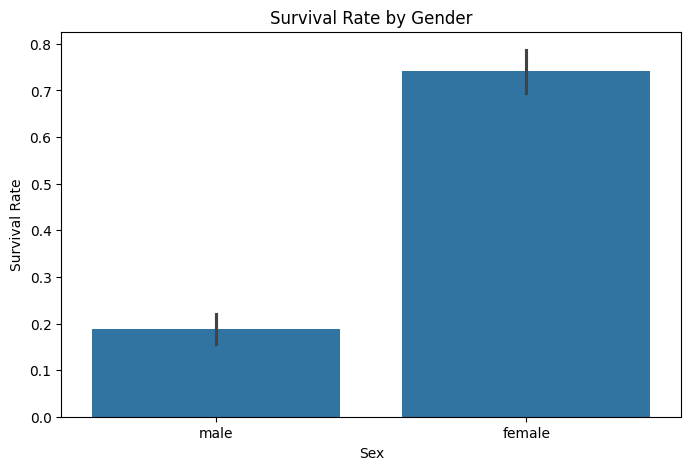

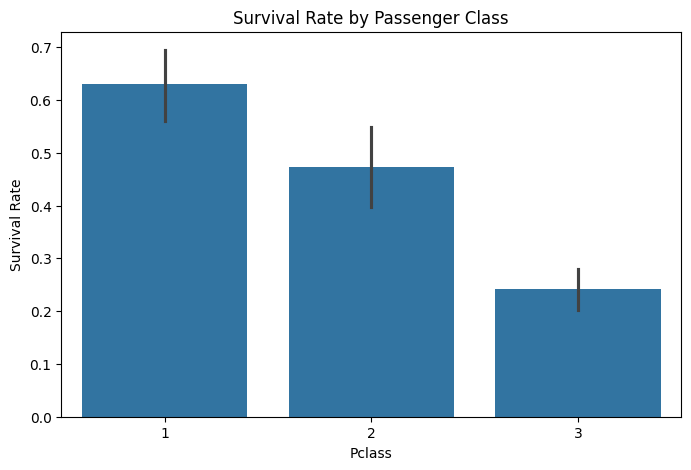

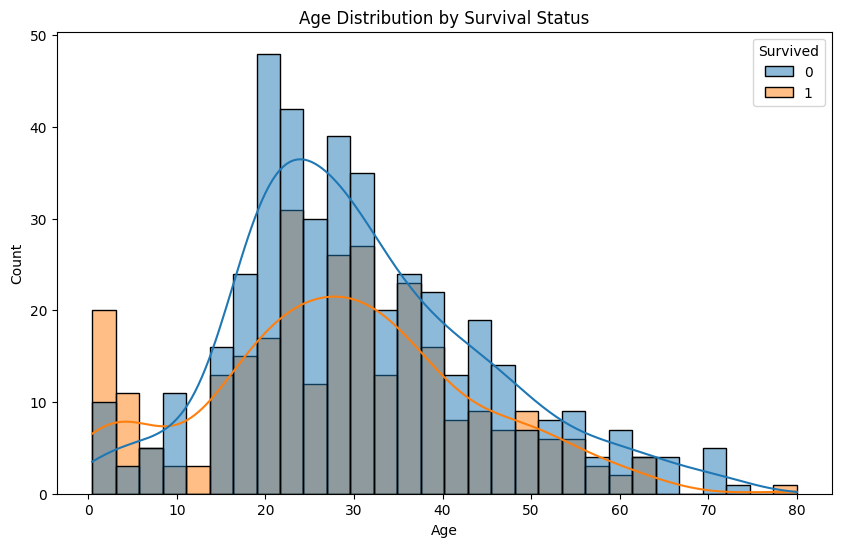

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Survival by Gender
plt.figure(figsize=(8,5))
sns.barplot(x='Sex', y='Survived', data=train)
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

# 2. Survival by Passenger Class
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y='Survived', data=train)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

# 3. Age Distribution
plt.figure(figsize=(10,6))
sns.histplot(data=train, x='Age', hue='Survived', kde=True, bins=30)
plt.title('Age Distribution by Survival Status')
plt.show()

Top 10 Important Features:
                Feature  Importance
11             Title_Mr    0.261460
1                   Sex    0.126519
0                Pclass    0.073053
13           Title_Rare    0.051808
9              HasCabin    0.046857
21               Deck_U    0.042464
7            FamilySize    0.033148
32  FamilySizeBin_Small    0.025275
5                  Fare    0.020053
17               Deck_E    0.019589


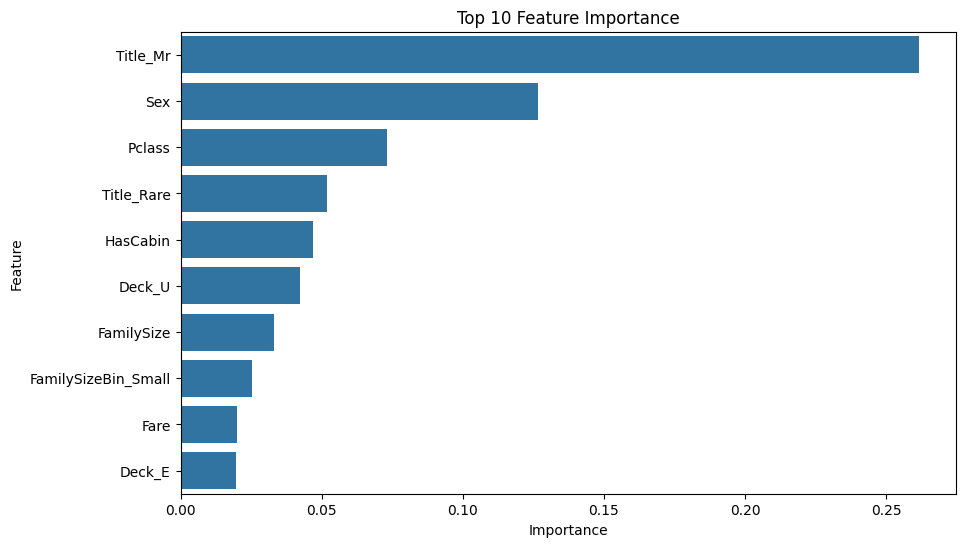

In [8]:
# Feature Importance (using Random Forest or XGBoost)
import pandas as pd

# If you used RandomForest in your final model, run this:
# Assuming 'model' is your trained model from earlier cells
if 'model' in globals():
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print("Top 10 Important Features:")
    print(feature_importance.head(10))

    # Plot
    plt.figure(figsize=(10,6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
    plt.title('Top 10 Feature Importance')
    plt.show()
else:
    print("Please run your model training cell first.")


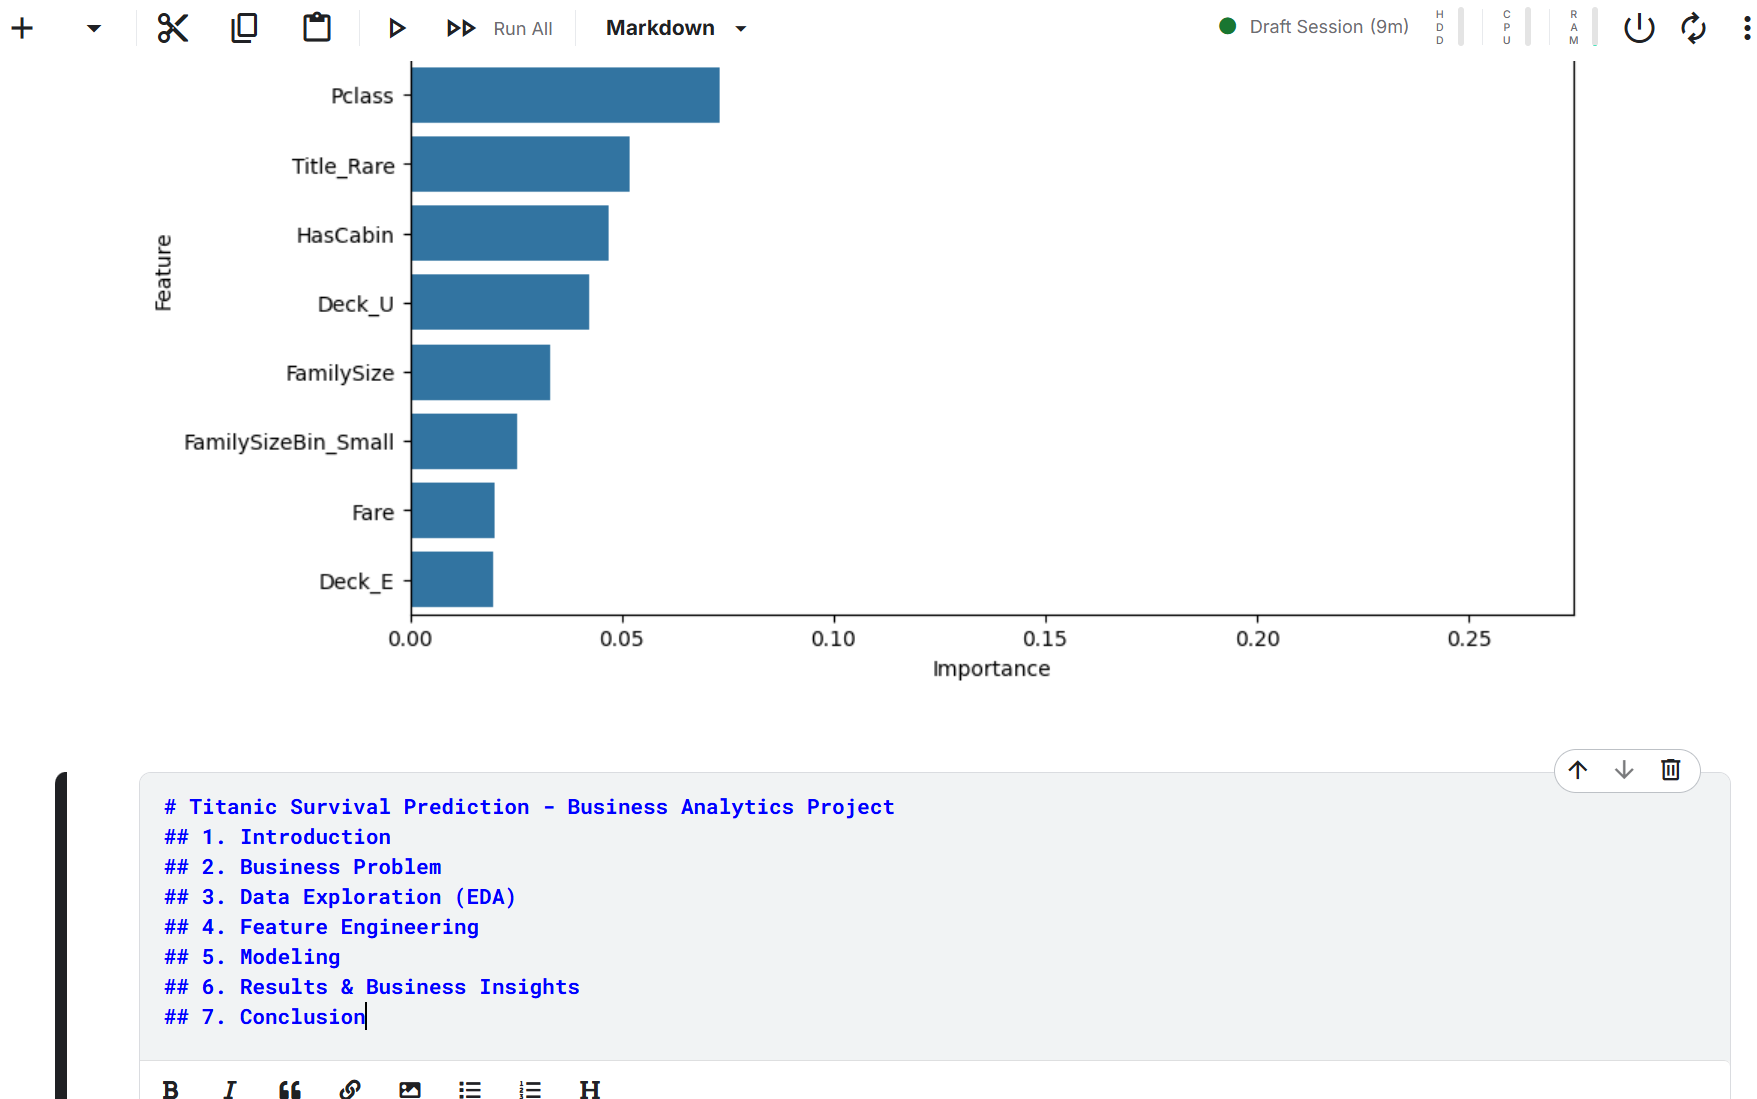

## Business Insights and Recommendations

### Key Findings
- Gender is the strongest predictor: Female survival rate is much higher than male.
- Passenger Class shows strong socio-economic effect.
- Age and family status also play important roles.

### Business Applications (International Business Perspective)
- Companies can design better priority systems in crisis situations.
- High-value customers (higher Pclass/Fare) deserve premium service.
- Customer segmentation based on vulnerability can improve retention and risk management.

This analysis combines technical machine learning with actionable business strategy.